<a href="https://colab.research.google.com/github/Bryan-ing/Master-s-Degree-in-AI/blob/main/Tarea_Variables_Aleatorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Clase 2: Variables Aleatorias
## Maestría en Inteligencia Artificial

**Dataset:** NSFG (National Survey of Family Growth)

### Instrucciones
Completa los ejercicios marcados con **# TU CÓDIGO AQUÍ**. Cada ejercicio tiene pistas para ayudarte.

---
## 0. Configuración Inicial

In [ ]:
# Importar librerías
!pip install empiricaldist #libreria creada por Allen Downey
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from empiricaldist import Pmf, Cdf

%matplotlib inline

print("Librerías importadas")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=f57f82e2ee00fa23eab64d3a1913aed7fd1d473522d34477187f8734cf3a19f4
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist
Librerías importadas


---
## 1. Cargar el Dataset NSFG

In [ ]:
# Descargar y cargar datos NSFG
import os
import gzip
from urllib.request import urlretrieve

# CORREGIDO: cambiado "data/ " por "code/" (sin espacio)
base_url = 'https://github.com/AllenDowney/ThinkStats2/raw/ed53b15755e08fccfdac07af5e5aac76e4507731/code/' #copiamos la url y quitamos lo ultimo del nombre del file

# Tu ciclo for se encargará de completar el link así: base_url + '2002FemPreg.dct'

for file in ['2002FemPreg.dct', '2002FemPreg.dat.gz']:
    if not os.path.exists(file):
        urlretrieve(base_url + file, file)

# Función para leer datos
def read_nsfg_data(dct_file, dat_file):
    columns_info = [
        ('caseid', 1, 12, int),
        ('prglngth', 275, 276, int),
        ('outcome', 277, 277, int),
        ('birthord', 278, 279, int),
        ('birthwgt_lb', 284, 285, int),
        ('birthwgt_oz', 286, 287, int),
        ('agepreg', 300, 303, int),
        ('totalwgt_lb', 312, 315, float),
    ]
    with gzip.open(dat_file, 'rt') as f:
        lines = f.readlines()
    data = []
    for line in lines:
        record = {}
        for col_name, start, end, col_type in columns_info:
            try:
                value = line[start-1:end].strip()
                record[col_name] = col_type(value) if value else np.nan
            except:
                record[col_name] = np.nan
        data.append(record)
    return pd.DataFrame(data)

df = read_nsfg_data('2002FemPreg.dct', '2002FemPreg.dat.gz')
live_births = df[df['outcome'] == 1].copy() #variable para los naciemientos vivos
print(f"Datos cargados: {len(live_births):,} nacimientos vivos")

Datos cargados: 9,148 nacimientos vivos


---
## 2. PMF de la Duración del Embarazo

### EJERCICIO 1: Crear y Visualizar PMF

In [ ]:
# EJERCICIO 1.1: Crea la PMF de la duración del embarazo
# PISTA: Usa Pmf.from_seq() con la columna 'prglngth'

# TU CÓDIGO AQUÍ
duracion = live_births['prglngth'].dropna()
pmf_duracion = Pmf.from_seq(duracion) #Probability Mass Function - from_seq probabilidades (0 a 1)

print("PMF de Duración del Embarazo:")
print(pmf_duracion.head(10)) #head como en linux

PMF de Duración del Embarazo:
prglngth
0     0.000109
4     0.000109
9     0.000109
13    0.000109
17    0.000219
18    0.000109
19    0.000109
20    0.000109
21    0.000219
22    0.000765
Name: , dtype: float64


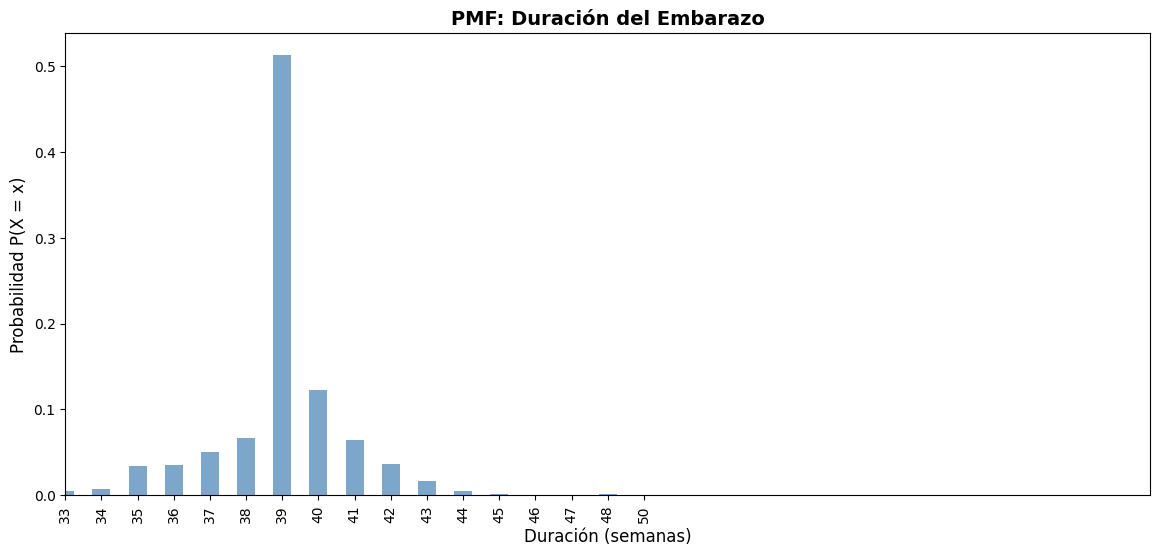

In [ ]:
# EJERCICIO 1.2: Visualiza la PMF
# Crea un gráfico de barras mostrando la PMF

fig, ax = plt.subplots(figsize=(14, 6))

# TU CÓDIGO AQUÍ
# Grafica la PMF (usa pmf_duracion.plot() con kind='bar')
pmf_duracion.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7) #kind=bar esto le dice que genere un grafico de barras

ax.set_xlabel('Duración (semanas)', fontsize=12)
ax.set_ylabel('Probabilidad P(X = x)', fontsize=12)
ax.set_title('PMF: Duración del Embarazo', fontsize=14, fontweight='bold')
ax.set_xlim(20, 50)
plt.show()

In [ ]:
# EJERCICIO 1.3: Calcula probabilidades específicas usando la PMF

# TU CÓDIGO AQUÍ
p_38 = pmf_duracion[38]  # Probabilidad de exactamente 38 semanas dentro del indice
p_39 = pmf_duracion[39]  # Probabilidad de exactamente 39 semanas
p_40 = pmf_duracion[40]  # Probabilidad de exactamente 40 semanas

print(f"Probabilidades específicas:")
print(f"  P(X = 38) = {p_38:.4f} ({p_38*100:.2f}%)") #dos decimales
print(f"  P(X = 39) = {p_39:.4f} ({p_39*100:.2f}%)")
print(f"  P(X = 40) = {p_40:.4f} ({p_40*100:.2f}%)")
print(f"\n  P(38 ≤ X ≤ 40) = {p_38 + p_39 + p_40:.4f}") #cuatro decimales que tan probable es que nazca en ese periodo

Probabilidades específicas:
  P(X = 38) = 0.0664 (6.64%)
  P(X = 39) = 0.5130 (51.30%)
  P(X = 40) = 0.1220 (12.20%)

  P(38 ≤ X ≤ 40) = 0.7014


---
## 3. CDF de la Duración del Embarazo

### EJERCICIO 2: Crear y Analizar CDF

In [ ]:
# EJERCICIO 2.1: Crea la CDF de la duración del embarazo
# PISTA: Usa Cdf.from_seq()

# TU CÓDIGO AQUÍ
cdf_duracion = Cdf.from_seq(duracion) # -> CDF significa Cumulative Distribution Function (Función de Distribución Acumulada) ordena de menor a mayor y

print("CDF de Duración del Embarazo (primeros 10 valores):")
print(cdf_duracion.head(10)) #imprime los primeros 10 valores
#Es inmune al ruido: Las gráficas de PMF pueden verse muy "picudas" y desordenadas. La CDF siempre es una curva suave que sube.
#Percentiles: La CDF te permite ver de inmediato dónde está el "medio" (la mediana). Donde la CDF cruza el 0.5, esa es la semana en la que el 50% de las mujeres ya dieron a luz.

CDF de Duración del Embarazo (primeros 10 valores):
prglngth
0     0.000109
4     0.000219
9     0.000328
13    0.000437
17    0.000656
18    0.000765
19    0.000875
20    0.000984
21    0.001202
22    0.001968
Name: , dtype: float64


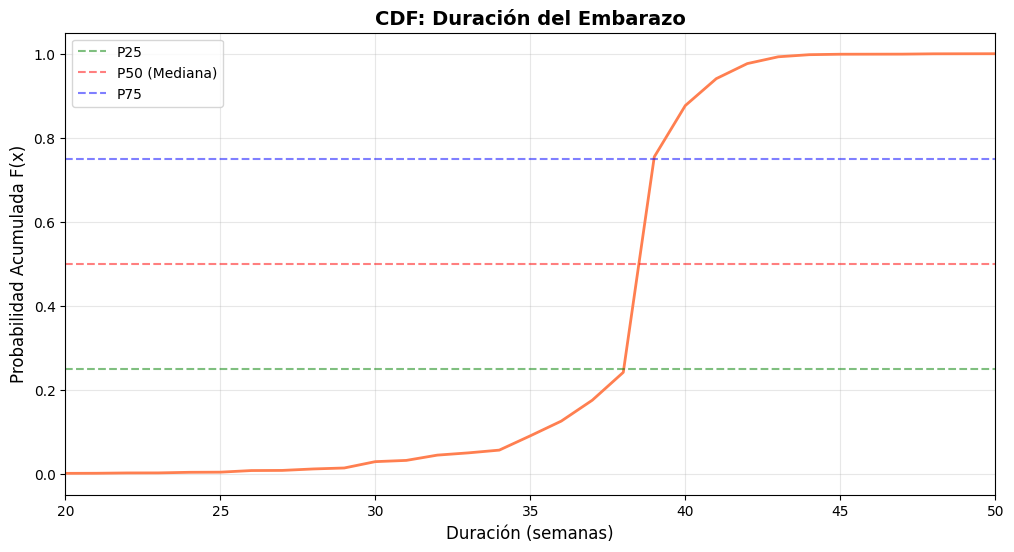

In [ ]:
# EJERCICIO 2.2: Visualiza la CDF

fig, ax = plt.subplots(figsize=(12, 6))

# TU CÓDIGO AQUÍ
cdf_duracion.plot(ax=ax, color='coral', linewidth=2) #funcion de la libreria de Allen

# Añadir líneas de referencia para percentiles
ax.axhline(y=0.25, color='green', linestyle='--', alpha=0.5, label='P25')
ax.axhline(y=0.50, color='red', linestyle='--', alpha=0.5, label='P50 (Mediana)')
ax.axhline(y=0.75, color='blue', linestyle='--', alpha=0.5, label='P75')

ax.set_xlabel('Duración (semanas)', fontsize=12)
ax.set_ylabel('Probabilidad Acumulada F(x)', fontsize=12)
ax.set_title('CDF: Duración del Embarazo', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(20, 50)
plt.show()

In [ ]:
# EJERCICIO 2.3: Usa la CDF para calcular probabilidades

# TU CÓDIGO AQUÍ
p_menor_37 = cdf_duracion[37]  # P(X ≤ 37) - probabilidad de parto prematuro
p_menor_40 = cdf_duracion[40]  # P(X ≤ 40) calculo de partos menores o iguales a 40
p_menor_42 = cdf_duracion[42]  # P(X ≤ 42) partos menores o iguales a 42 semanas

# Probabilidad de estar entre 37 y 42 semanas (término)
p_termino = p_menor_42 - p_menor_37

print(f"Probabilidades calculadas con CDF:")
print(f"  P(X ≤ 37) = {p_menor_37:.4f} ({p_menor_37*100:.2f}%) → Parto prematuro")
print(f"  P(X ≤ 40) = {p_menor_40:.4f} ({p_menor_40*100:.2f}%)")
print(f"  P(X ≤ 42) = {p_menor_42:.4f} ({p_menor_42*100:.2f}%)")
print(f"\n  P(37 < X ≤ 42) = {p_termino:.4f} ({p_termino*100:.2f}%) → A término")

Probabilidades calculadas con CDF:
  P(X ≤ 37) = 0.1751 (17.51%) → Parto prematuro
  P(X ≤ 40) = 0.8765 (87.65%)
  P(X ≤ 42) = 0.9765 (97.65%)

  P(37 < X ≤ 42) = 0.8014 (80.14%) → A término


---
## 4. Comparación PMF: Primeros Bebés vs Otros

### EJERCICIO 3: Comparar Distribuciones

In [ ]:
# EJERCICIO 3.1: Separa los datos y crea las PMFs

# TU CÓDIGO AQUÍ
primeros = live_births[live_births['birthord'] == 1]['prglngth'].dropna() #primogenitos filtramos columna de duración de embarazo
otros = live_births[live_births['birthord'] != 1]['prglngth'].dropna() #2os 3os... y filtramos columna que nos interesa de duración de embarazo

# Crea las PMFs
pmf_primeros = Pmf.from_seq(primeros)
pmf_otros = Pmf.from_seq(otros)

print(f"Datos separados:")
print(f"  Primeros bebés: {len(primeros):,} casos") #len cuenta cuantos hay en ese grupo
print(f"  Otros bebés: {len(otros):,} casos")

Datos separados:
  Primeros bebés: 4,413 casos
  Otros bebés: 4,735 casos


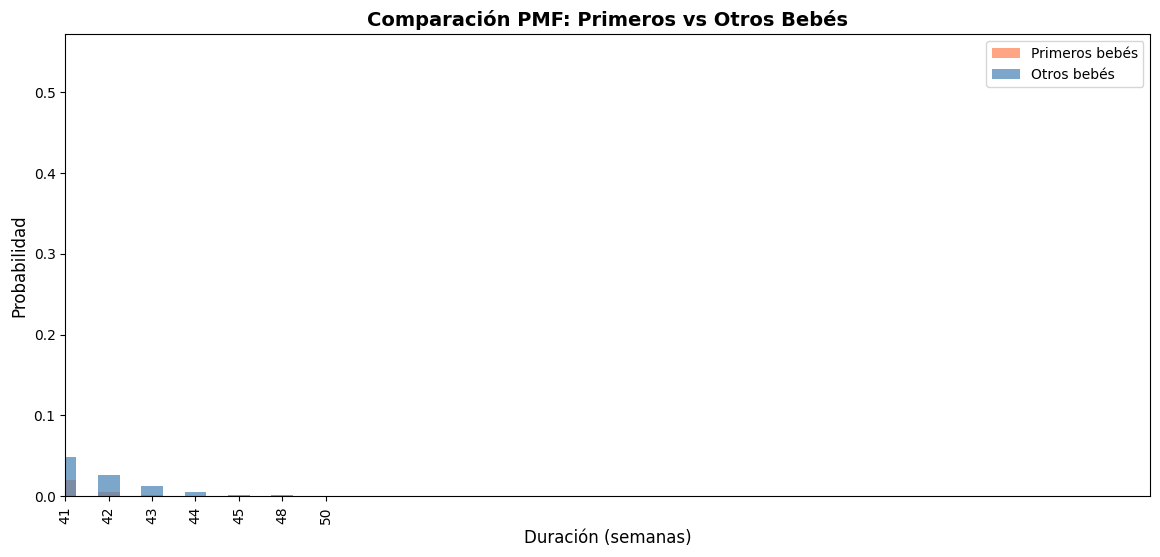

In [ ]:
# EJERCICIO 3.2: Visualiza ambas PMFs en el mismo gráfico

fig, ax = plt.subplots(figsize=(14, 6))

# TU CÓDIGO AQUÍ
# Grafica ambas PMFs con diferentes colores
pmf_primeros.plot(kind='bar', ax=ax, color='coral', alpha=0.7, label='Primeros bebés')
pmf_otros.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7, label='Otros bebés')

ax.set_xlabel('Duración (semanas)', fontsize=12)
ax.set_ylabel('Probabilidad', fontsize=12)
ax.set_title('Comparación PMF: Primeros vs Otros Bebés', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xlim(25, 50)
plt.show()

In [ ]:
# EJERCICIO 3.3: Compara probabilidades específicas

semanas = [35, 38, 39, 40, 41, 42]

print(f"{'Semanas':<10} {'Primeros':<12} {'Otros':<12} {'Diferencia':<12}")
print("-" * 50)

for s in semanas:
    # TU CÓDIGO AQUÍ
    p1 = pmf_primeros[s] if s in pmf_primeros else 0
    p2 = pmf_otros[s] if s in pmf_otros else 0
    diff = p1 - p2
    print(f"{s:<10} {p1:<12.4f} {p2:<12.4f} {diff:<12.4f}")

Semanas    Primeros     Otros        Diferencia  
--------------------------------------------------
35         0.0360       0.0321       0.0039      
38         0.0616       0.0707       -0.0091     
39         0.4790       0.5447       -0.0656     
40         0.1215       0.1225       -0.0010     
41         0.0816       0.0479       0.0336      
42         0.0465       0.0260       0.0205      


---
## 5. Simulación de Variables Aleatorias

### EJERCICIO 4: Simulación

In [ ]:
# EJERCICIO 4.1: Simula lanzamientos de dos dados
# Calcula la suma de ambos dados

np.random.seed(42)
n = 10000

# TU CÓDIGO AQUÍ
dado1 = np.random.randint(1, 7, size=n)
dado2 = np.random.randint(1, 7, size=n)
suma = dado1 + dado2

# Crea la PMF de la suma
pmf_suma = Pmf.from_seq(suma)

print("PMF de la suma de dos dados:")
print(pmf_suma)

PMF de la suma de dos dados:
2     0.0273
3     0.0608
4     0.0811
5     0.1101
6     0.1383
7     0.1616
8     0.1414
9     0.1105
10    0.0858
11    0.0556
12    0.0275
Name: , dtype: float64


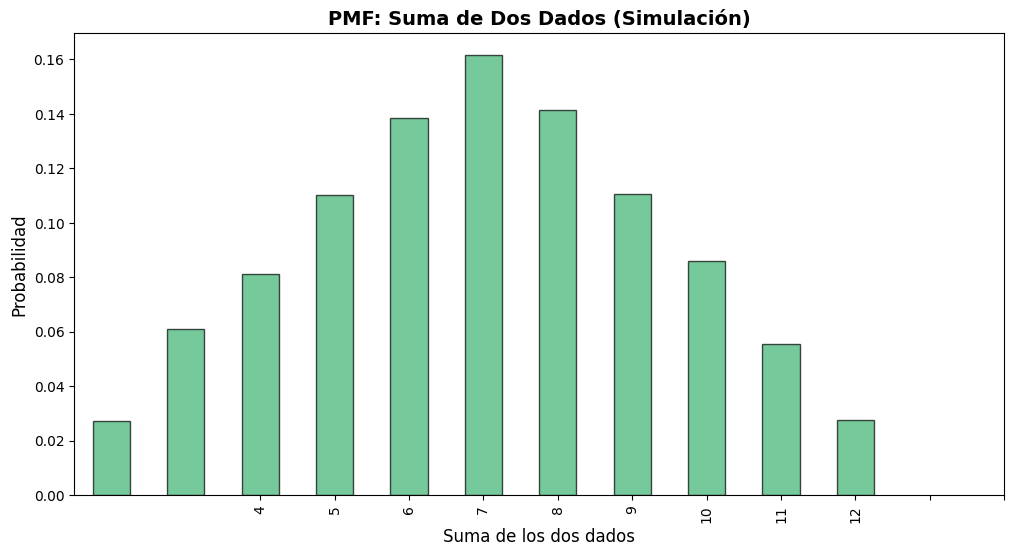


 La suma más probable es 7 con probabilidad 0.1616


In [ ]:
# EJERCICIO 4.2: Visualiza la PMF de la suma

fig, ax = plt.subplots(figsize=(12, 6))

# TU CÓDIGO AQUÍ
pmf_suma.plot(kind='bar', ax=ax, color='mediumseagreen', alpha=0.7, edgecolor='black') #llamamos la funcion anterior para visualizar los datos ya con las caracterisitcas

ax.set_xlabel('Suma de los dos dados', fontsize=12)
ax.set_ylabel('Probabilidad', fontsize=12)
ax.set_title('PMF: Suma de Dos Dados (Simulación)', fontsize=14, fontweight='bold')
ax.set_xticks(range(2, 13))
plt.show()

# ¿Cuál es la suma más probable?
suma_max = pmf_suma.idxmax()
prob_max = pmf_suma.max()
print(f"\n La suma más probable es {suma_max} con probabilidad {prob_max:.4f}")

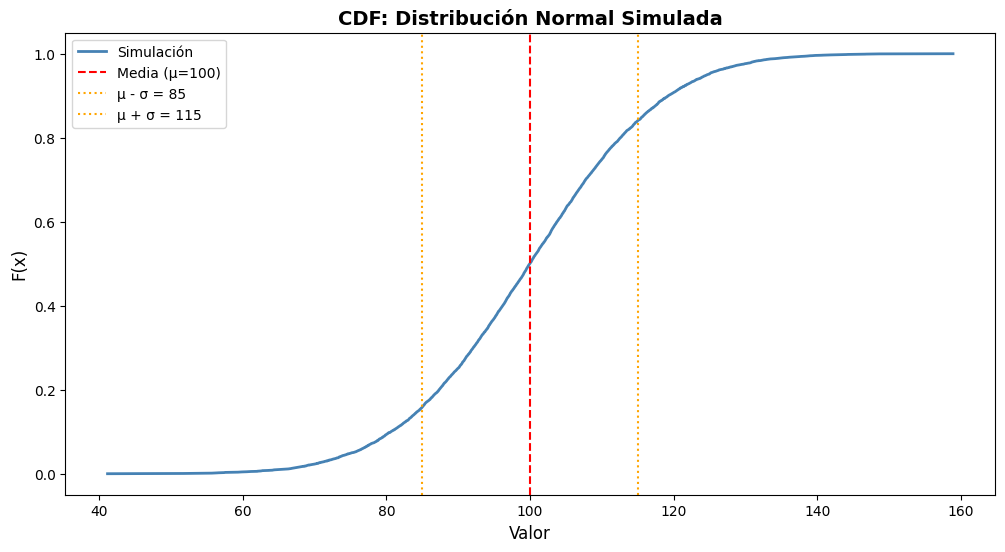


 Regla Empírica (68-95-99.7):
  P(μ - σ < X ≤ μ + σ) = P(85 < X ≤ 115) = 0.6820 (68.2%)
  (Teórico: 68.27%)


In [ ]:
# EJERCICIO 4.3: Simula una distribución normal y compara con la teórica

np.random.seed(42)

# TU CÓDIGO AQUÍ
# Simula 10000 valores de una normal con media 100 y desv. estándar 15
simulacion = np.random.normal(loc=100, scale=15, size=10000)

# Crea la CDF
cdf_sim = Cdf.from_seq(simulacion)

# Visualiza
fig, ax = plt.subplots(figsize=(12, 6))
cdf_sim.plot(ax=ax, color='steelblue', linewidth=2, label='Simulación')

# Añadir líneas para media ± desv estándar
ax.axvline(x=100, color='red', linestyle='--', label='Media (μ=100)')
ax.axvline(x=85, color='orange', linestyle=':', label='μ - σ = 85')
ax.axvline(x=115, color='orange', linestyle=':', label='μ + σ = 115')

ax.set_xlabel('Valor', fontsize=12)
ax.set_ylabel('F(x)', fontsize=12)
ax.set_title('CDF: Distribución Normal Simulada', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

# Verifica el 68-95-99.7 rule
p_68 = cdf_sim(115) - cdf_sim(85)
print(f"\n Regla Empírica (68-95-99.7):")
print(f"  P(μ - σ < X ≤ μ + σ) = P(85 < X ≤ 115) = {p_68:.4f} ({p_68*100:.1f}%)")
print(f"  (Teórico: 68.27%)")

---
## 6. Preguntas de Reflexión

**PREGUNTA 6.1:** Observando la PMF de la duración del embarazo, ¿qué valores tienen las probabilidades más altas? ¿Por qué crees que ocurre esto?

**TU RESPUESTA:** _Escribe tu respuesta aquí_

**PREGUNTA 6.2:** En la comparación de PMFs entre primeros bebés y otros, ¿observas alguna diferencia importante? ¿Qué podría explicar esta diferencia?

**TU RESPUESTA:** _Esto es debido a que en su mayoria es el tiempo optimo para un parto y en base a que no todos los parto natural el dataset arroja que este es el tiempo optimo, junto con las cesareas que son programadas en este lapso de tiempo, debido a esto arroja que en su mayoria son en este tiempo,_

**PREGUNTA 6.3:** Al sumar dos dados, ¿por qué la suma 7 es la más probable? Explica usando el concepto de combinaciones.

**TU RESPUESTA:** _Su probabilidad es mas alta debido a que el numero de combinaciónes es mucho mayor_

**PREGUNTA 6.4:** ¿Cuál es la ventaja de usar CDF sobre PMF para calcular probabilidades de intervalos? Da un ejemplo.

**TU RESPUESTA:** _La CDF es mucho más eficiente que la PMF porque para calcular rangos no tienes que sumar nada; simplemente haces una resta entre dos puntos de la curva. Mientras que en la PMF tendrías que ir sumando cada barrita una por una (lo cual es un mas complejo si el intervalo es largo), la CDF ya hizo todo ese trabajo de suma por ti y lo guardó en un valor acumulado. Por ejemplo, si quieres saber cuántos bebés nacen entre la semana 30 y la 38, en la PMF sumarías 30+31+32... hasta la 38, pero en la CDF solo restas el valor de la semana 38 menos el de la 29 y listo, tienes el resultado exacto con una sola operación. Además, la CDF es mejor cuando tienes datos con muchos decimales (como en la Normal) donde no hay valores exactos que sumar, permitiéndote sacar probabilidades de cualquier rango de forma continua y limpia.

Otro ejemplo seria si quiero analizar el voltaje en una bateria, si usamos la PMF, se tendría una gráfica con barritas para cada voltaje exacto (12.1V, 12.2V, etc.). Si quieres saber qué probabilidad hay de que la batería esté entre 11.5V y 12.5V, te tocaría buscar la barrita del 11.5, sumarle la del 11.6, luego la del 11.7 y así hasta llegar al final. Es una pérdida de tiempo y te puedes equivocar en una suma.

En cambio, con la CDF, nada más te fijas en cuánto valor acumulado hay en 12.5V y le restas lo que se acumuló hasta 11.4V. Es una sola resta y ya se tiene el porcentaje total de baterías que caen en ese rango. Es mucho más práctico para nosotros porque, si luego nos piden cambiar el rango, no tienes que volver a sumar todo desde cero, solo checas los dos puntos nuevos en la curva y listo. Además, si el multímetro te da valores con mil decimales (como 12.153V), la PMF ya no te sirve porque no hay una "barra" para ese número exacto, pero en la curva de la CDF siempre puedes encontrar el punto exacto y hacer la resta._

---
## Checklist de Entrega

- [ ] Todos los ejercicios de código están completos
- [ ] Las visualizaciones se muestran correctamente
- [ ] Las preguntas de reflexión están respondidas
- [ ] El notebook se ejecuta sin errores

**Formato de entrega:** Sube el archivo `.ipynb` a la plataforma del curso.